<img src="../img/images.jpg" height="200" width="370"/>  <img src="../img/grad_cam.jpg" height="200" width="370"/> 
# 🩺 Détection de Pneumonie sur Radiographies Thoraciques utilisant le Transfer/Ensemble Learning (à partir de modèles pré-entraînés de type CNN)

# Contexte du projet


Une équipe médicale souhaite tester l’apport de l’intelligence artificielle dans **le diagnostic automatisé de la pneumonie à partir de radios thoraciques.** Elle a besoin d’un prototype fonctionnel (Proof of Concept) permettant de démontrer la faisabilité d’**un système de classification binaire d’images médicales**.

>Le problème posé consiste à réutiliser un modèle de vision par ordinateur **pré-entraîné (type CNN)** pour l’adapter au contexte médical, sans repartir d’un entraînement complet.

> Dans une logique de mise en production à moyen terme, il est également attendu de documenter et tracer les expérimentations réalisées. L’usage de **MLflow** est proposé pour initier cette démarche, en assurant le suivi des performances, la traçabilité des essais et la gestion des versions de modèles dans une perspective MLOps.

----

# 1. Chargement des bibliothèques nécessaires

 - Création manuelle d'un environnment virtuel `python -m venv .venv` et l'activer ` .\.venv\Scripts\Activate.ps1` (sous windows os)
 - Installer les bibliothèques `pip install -r requirements.txt` 
 - choisir le dossier .venv dans "Python: Select interpreter" (Command Palette)
 (venv contenant python 3.10 compatible avec tensorflow)
 - installer ipykernel pour executer

In [10]:
import os  # os pour manipuler des dossiers et fichiers
import sys
import numpy as np # np pour manipuler des vecteurs et matrices
import pandas as pd # pd pour traiter des dataframe et visualiser des figures
import seaborn as sns # pd pour visualiser des figures

import mlflow #  pour documenter et tracer les expérimentations réalisées.
import mlflow.tensorflow
# DL Lib
import tensorflow as tf 

from tensorflow.keras.layers import Input,Dense, Dropout, GlobalAveragePooling2D,Concatenate
from tensorflow.keras.applications import DenseNet121, ResNet50V2
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

import matplotlib.pyplot as plt  #  pour visualiser des figures
from tensorflow.keras.utils import plot_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import roc_curve,roc_auc_score,auc, confusion_matrix, classification_report,accuracy_score # pd pour évaluer le modèle
import cv2


# 2. Préparation et exploration du dataset

[[[ 24  24  24]
  [ 20  20  20]
  [ 19  19  19]
  ...
  [ 95  95  95]
  [ 94  94  94]
  [ 95  95  95]]

 [[ 22  22  22]
  [ 22  22  22]
  [ 17  17  17]
  ...
  [ 91  91  91]
  [ 95  95  95]
  [ 95  95  95]]

 [[ 24  24  24]
  [ 21  21  21]
  [ 20  20  20]
  ...
  [ 93  93  93]
  [ 93  93  93]
  [ 92  92  92]]

 ...

 [[ 29  29  29]
  [ 29  29  29]
  [ 29  29  29]
  ...
  [ 61  61  61]
  [ 59  59  59]
  [ 59  59  59]]

 [[ 34  34  34]
  [ 33  33  33]
  [ 35  35  35]
  ...
  [ 79  79  79]
  [ 81  81  81]
  [ 82  82  82]]

 [[ 46  46  46]
  [ 45  45  45]
  [ 45  45  45]
  ...
  [108 108 108]
  [113 113 113]
  [110 110 110]]]


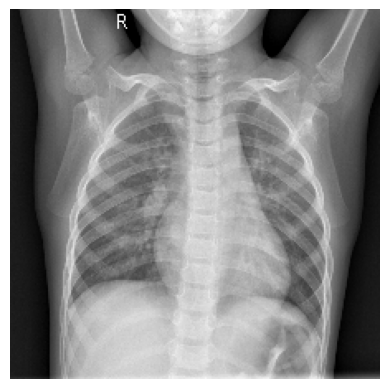

Shape (dimensions)    : (224, 224, 3)
Type des valeurs      : uint8


In [11]:
# On charge une image depuis le répertoire data/
img = cv2.imread("../data/train/NORMAL/IM-0115-0001.jpeg", cv2.IMREAD_GRAYSCALE)
# Convert to 3 channels
img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB) # Now shape is (H, W, 3)
# Resize to model input size (e.g., 224x224)
resized_img = cv2.resize(img_rgb, (224, 224))
# Observer l'image sous forme de matrice
print(resized_img)

# Visualisation de l'image
plt.imshow(resized_img, cmap="gray")
plt.axis("off")
plt.show()

# Inspection des métadonnées de l'image
print(f"Shape (dimensions)    : {resized_img.shape}")
print(f"Type des valeurs      : {resized_img.dtype}")

## Chargement des données

In [12]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

# Create ImageDataGenerator instances & normalization
train_datagen = ImageDataGenerator(rescale=1./255)  
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Load datasets
train_generator = train_datagen.flow_from_directory(
    '../data/train',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    color_mode='rgb'  # Converts grayscale to 3 channels automatically
)

val_generator = val_datagen.flow_from_directory(
    '../data/val',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    color_mode='rgb'
)

test_generator = test_datagen.flow_from_directory(
    '../data/test',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    color_mode='rgb',
    shuffle=False  # Usually better for evaluation
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


## Vérification

In [ ]:
import sys
import os

# Go one directory up from notebooks to find utils
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from utils.functions_data import generator_to_numpy
# Convert generators to NumPy arrays
X_train, y_train = generator_to_numpy(train_generator)
X_val, y_val = generator_to_numpy(val_generator)
X_test, y_test = generator_to_numpy(test_generator)

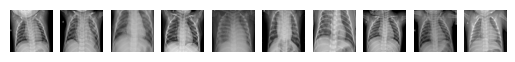

In [14]:
# Vérification des données préparées
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(X_train[i], cmap="grey")
   
    plt.axis("off")

plt.show()

# 3. Modélisation & compilation (ensemble learning)

- Pour un transfer learning : choisir selon les performances le modèle de base pré-entrainé (DenseNet121, ResNet50v2 ...) sur les données ImageNet
- Pour un ensemble learning : combiner plusieurs modèles ensemble

In [15]:
input_tensor1 = Input(shape=(224,224,3))
input_tensor2 = Input(shape=(224,224,3))

base_model_densenet = DenseNet121(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model_resnet = ResNet50V2(weights='imagenet', include_top=False, input_shape=(224,224,3))

base_model_densenet.trainable = False
base_model_resnet.trainable = False

feat1 = base_model_densenet(input_tensor1)
feat2 = base_model_resnet(input_tensor2)

feat1 = GlobalAveragePooling2D()(feat1)
feat2 = GlobalAveragePooling2D()(feat2)

concat = Concatenate()([feat1, feat2])
x = Dense(256, activation='relu')(concat)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

model_ensemble = Model(inputs=[input_tensor1, input_tensor2], outputs=output)
model_ensemble.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])
    


---

# 4. Mlflow tracking 

In [16]:
mlflow.tensorflow.autolog()
mlflow.set_experiment("EnsembleLearning_TransferCNN")

<Experiment: artifact_location='file:///c:/Users/User/Desktop/DL_transfer_CNN_pneumonia/notebooks/mlruns/590754832705215518', creation_time=1748352294806, experiment_id='590754832705215518', last_update_time=1748352294806, lifecycle_stage='active', name='EnsembleLearning_TransferCNN', tags={}>

## Fitting & Logging

In [18]:
with mlflow.start_run(run_name="new-run-concat-ensemble-dual_input"):
     history_ensemble = model_ensemble.fit(
    [X_train, X_train], y_train,
    validation_data=([X_val, X_val], y_val),
    batch_size=32,
    epochs=5

)
     # log the model
     mlflow.keras.log_model(model_ensemble,"model_ensemble_dual_input")
     mlflow.tensorflow.save_model(model_ensemble,"../models/my_model_ensemble")
    
    

2025/05/27 20:19:10 WARNING mlflow.tensorflow: Unrecognized dataset type <class 'list'>. Dataset logging skipped.
2025/05/27 20:19:10 WARNING mlflow.tensorflow: Failed to log training dataset information to MLflow Tracking. Reason: 'list' object has no attribute 'flatten'


Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.8547 - loss: 0.3188

163/163 ━━━━━━━━━━━━━━━━━━━━ 1042s 6s/step - accuracy: 0.8550 - loss: 0.3182 - val_accuracy: 0.7500 - val_loss: 0.4472
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9573 - loss: 0.1141

163/163 ━━━━━━━━━━━━━━━━━━━━ 1119s 7s/step - accuracy: 0.9573 - loss: 0.1141 - val_accuracy: 0.9375 - val_loss: 0.3123
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 1012s 6s/step - accuracy: 0.9648 - loss: 0.0902 - val_accuracy: 0.8125 - val_loss: 0.3632
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 1053s 6s/step - accuracy: 0.9674 - loss: 0.0844 - val_accuracy: 0.8125 - val_loss: 0.4624
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 1211s 7s/step - accuracy: 0.9740 - loss: 0.0718 - val_accuracy: 0.8125 - val_loss: 0.3540


2025/05/27 21:50:13 WARNING mlflow.tensorflow: Failed to infer model signature: could not sample data to infer model signature: Cannot log input example or model signature for input with type <class 'list'>. TensorFlow Keras autologging can only log input examples and model signatures for the following input types: numpy.ndarray, dict[string -> numpy.ndarray], tensorflow.keras.utils.Sequence, and tensorflow.data.Dataset (TensorFlow >= 2.1.0 required)
2025/05/27 21:50:13 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.
2025/05/27 21:50:53 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2025/05/27 21:50:54 WARNING mlflow.keras.save: You are saving a Keras model without 

MlflowException: Path 'c:\Users\User\Desktop\DL_transfer_CNN_pneumonia\models\my_model_ensemble' already exists and is not empty

In [ ]:
model_ensemble.save('../models/model_ensemble_dual_input.keras')

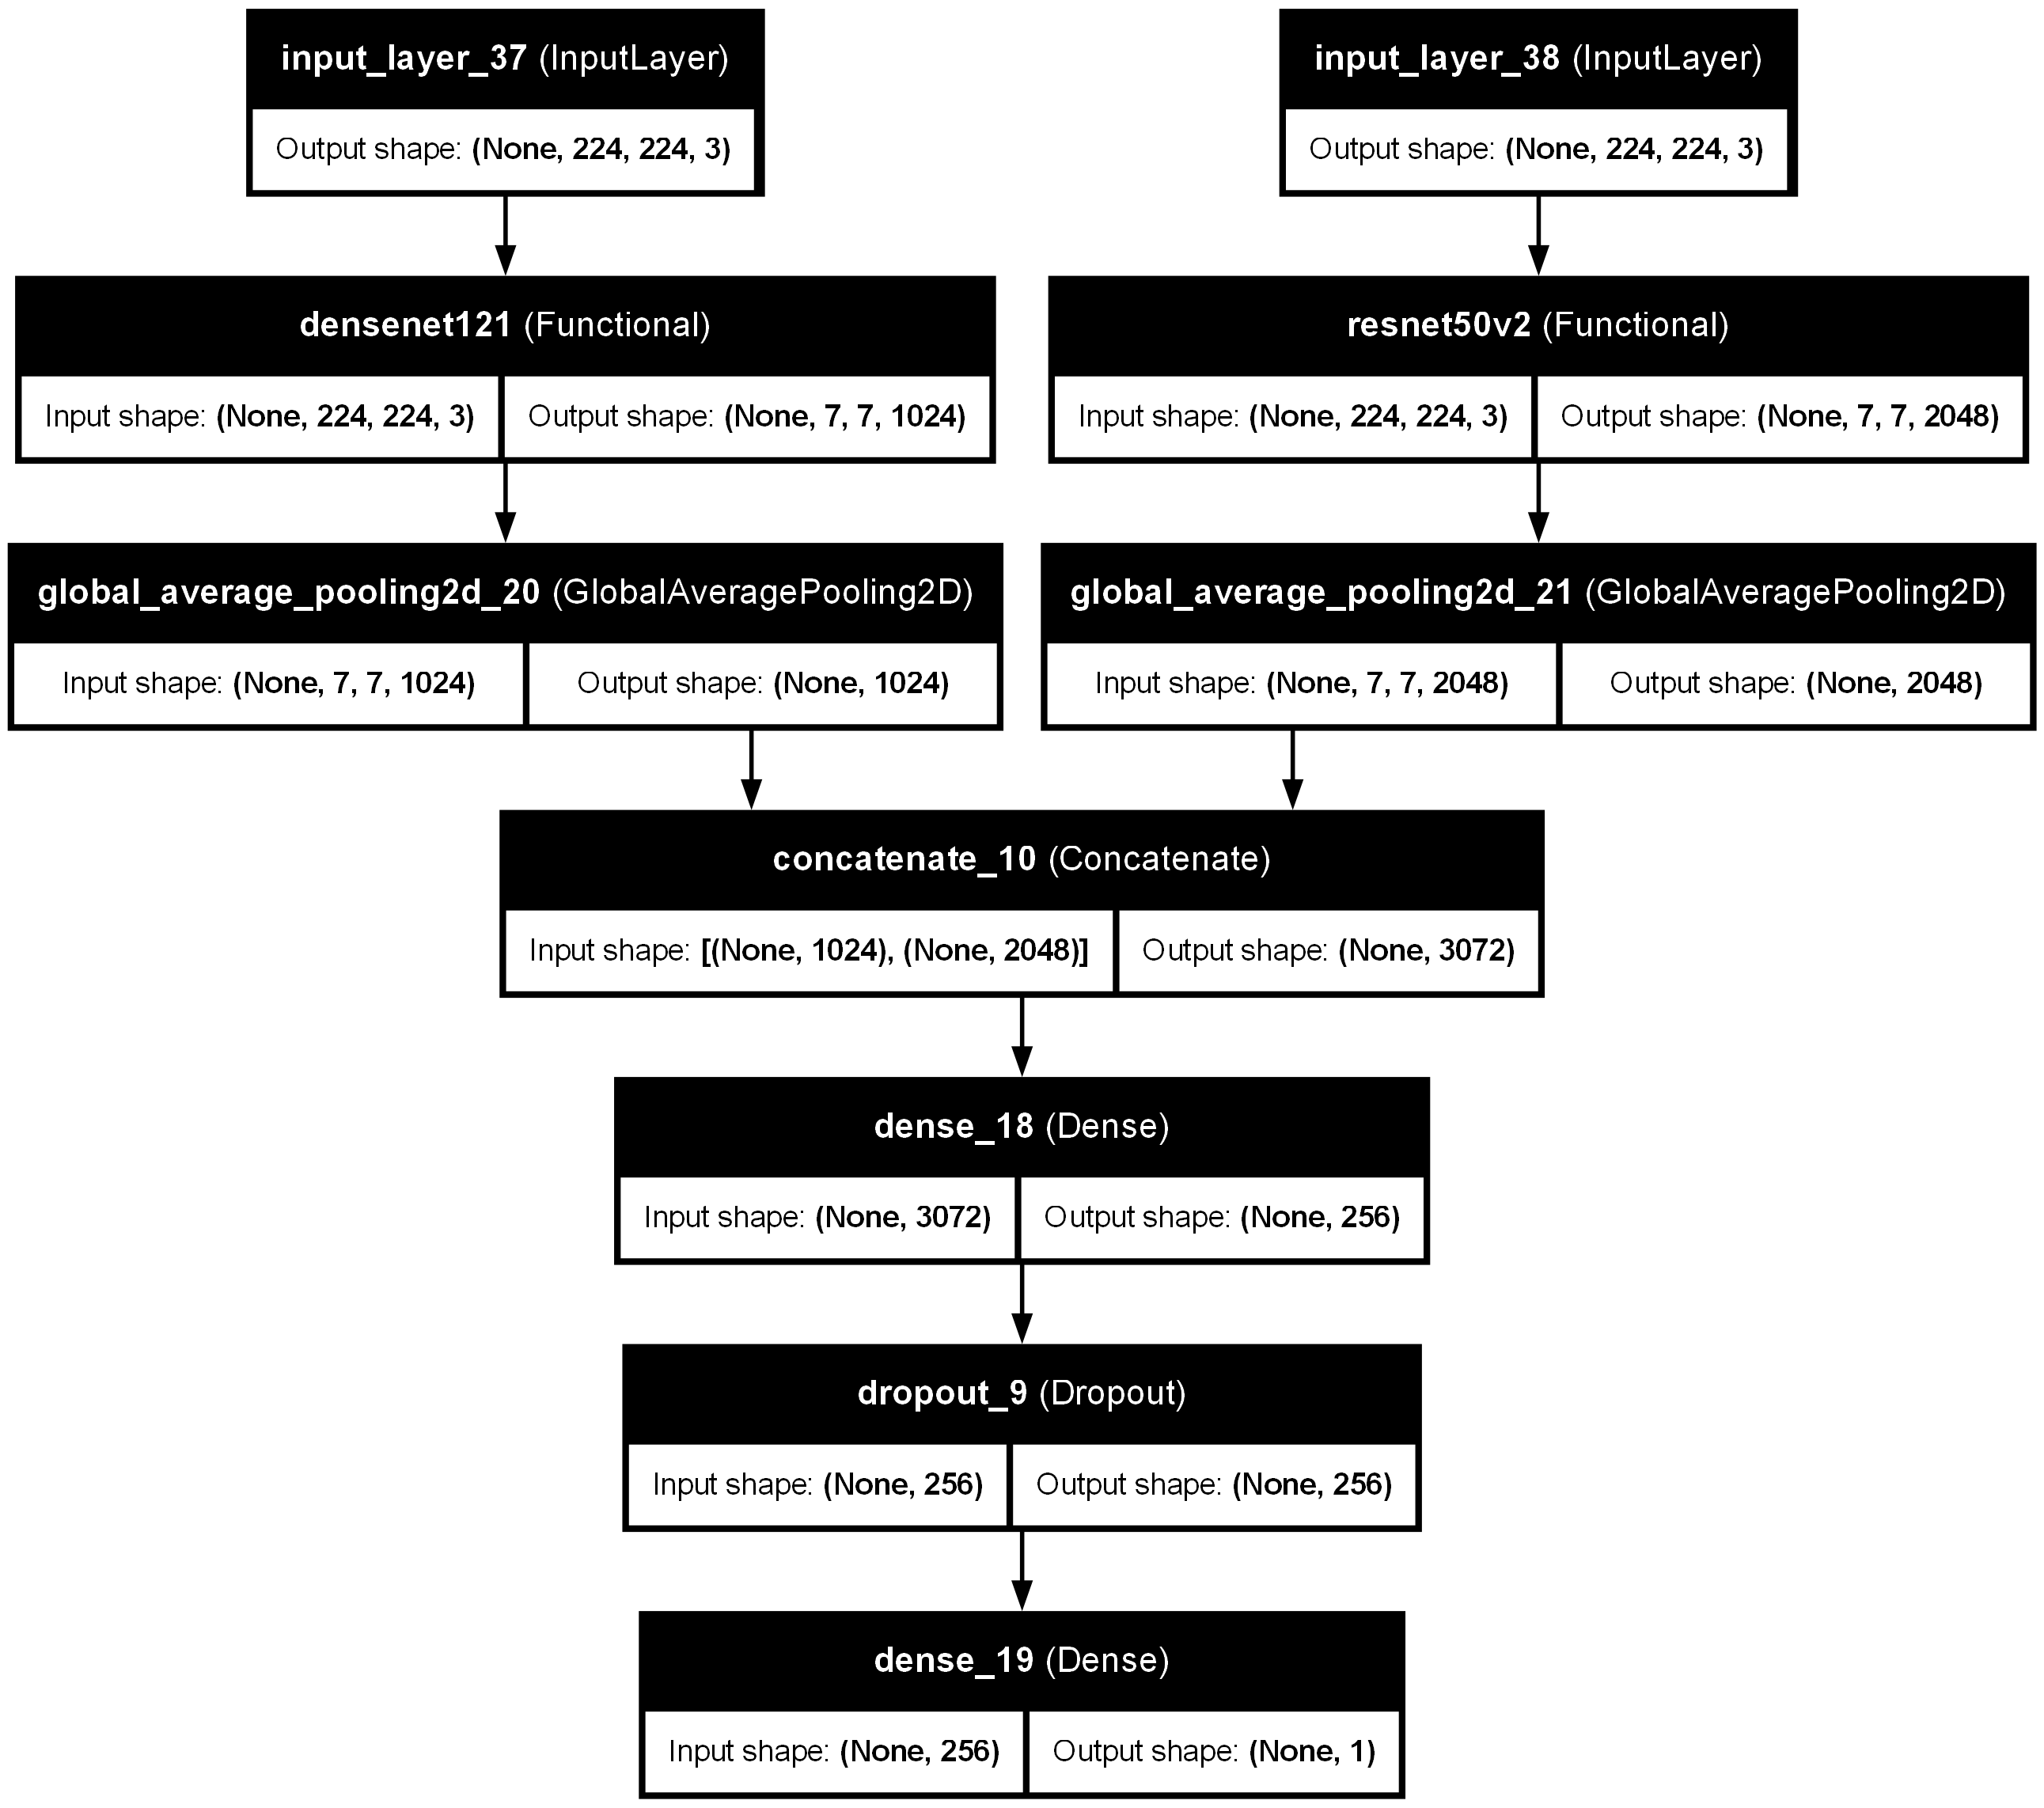

In [ ]:
plot_model(model_ensemble, to_file='../figures/ensemble/model_ensemble_architecture.png', show_shapes=True, show_layer_names=True)


# 5. Evaluation

20/20 ━━━━━━━━━━━━━━━━━━━━ 119s 6s/step
Confusion Matrix:
 [[129 105]
 [  6 384]]


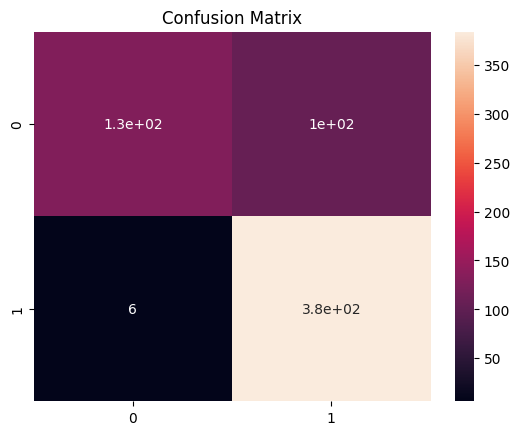

Classification Report:

              precision    recall  f1-score   support

      Normal       0.96      0.55      0.70       234
   Pneumonia       0.79      0.98      0.87       390

    accuracy                           0.82       624
   macro avg       0.87      0.77      0.79       624
weighted avg       0.85      0.82      0.81       624



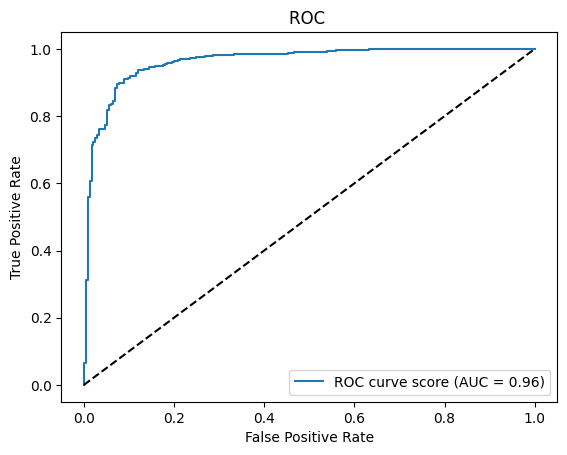

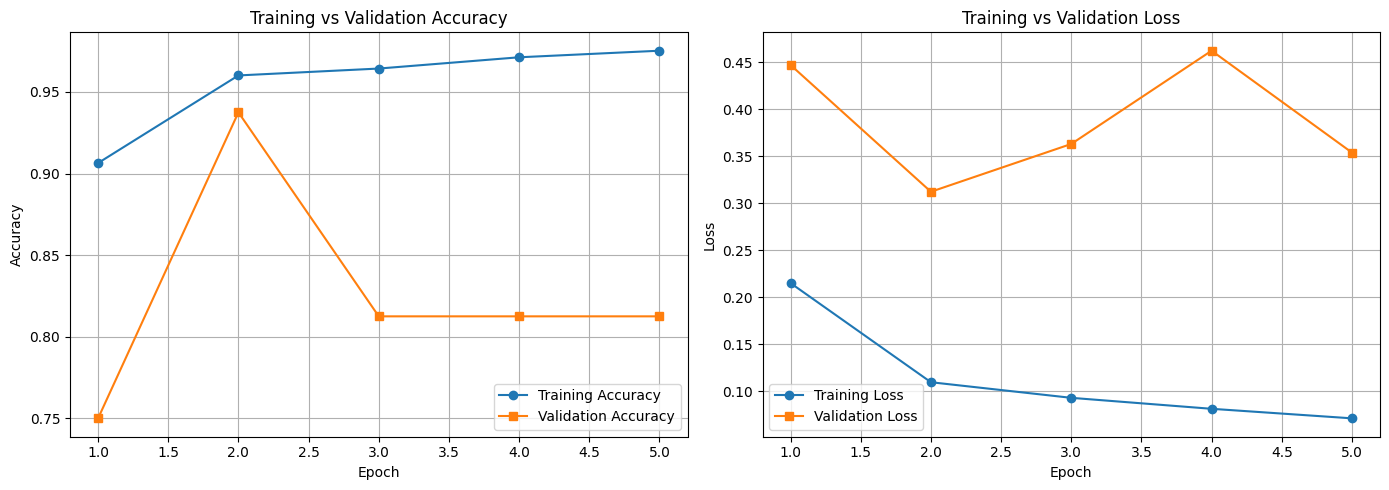

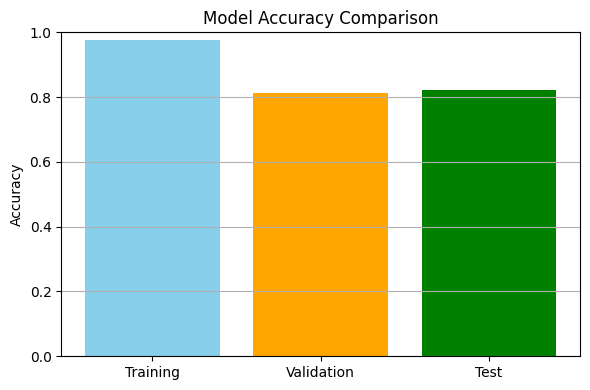

In [23]:

from utils.drawing_figures import draw_accuracy_train_val_test, draw_confusion_matrix, draw_models_acc, draw_roc_curve, draw_train_val_acc_loss
mlflow.end_run()
mlflow.start_run()
# Get predictions on test data


y_pred_prob = model_ensemble.predict([X_test,X_test])
y_pred = (y_pred_prob > 0.5).astype(int)



path = "../figures/ensemble/"

# Confusion matrix
draw_confusion_matrix(y_test,y_pred,path)


# Classification report
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Pneumonia']))

# ROC score
draw_roc_curve(y_test,y_pred_prob,path)


# Accuracy & loss subplots
draw_train_val_acc_loss(history_ensemble,path)


# Model accuracy train vs val vs test
draw_accuracy_train_val_test(model_ensemble,history_ensemble,X_test,y_test,True,path)



# 6. Comparaison des modèles

In [29]:
from utils.drawing_figures import draw_models_acc

models_path = "../models/"
figures_path = "../figures/"
draw_models_acc(models_path,figures_path,X_test,y_test)
    

model_densenet
../models/model_densenet.keras
dual
model_ensemble_dual_input
../models/model_ensemble_dual_input.keras
model_resnet
../models/model_resnet.keras
model_vgg
../models/model_vgg.keras
models loaded
dual model <Functional name=functional, built=True> label model_ensemble_dual_input


KeyboardInterrupt: 

==> Le modèle basé sur Densnet est le meilleur en terme d'accuracy.

---

# Mlflow ui
Pour visualiser les expérimentations suivies 
- changer de répertoire:
cd  notebooks/
- entrer la commande
`mlflow ui `
- ouvrir http://localhost:5000